# Data Prep: EV Charging Patterns (Dataset 4)

Raw file: `data/raw/4-ev_charging_patterns.csv`

**Target (regression):** `Energy Consumed (kWh)`

Pipeline aligned with `5-EV_energy_consumption_data_prep.ipynb`: missing values → duplicates → categorical encoding → outlier capping → 60/20/20 split → `StandardScaler` on continuous features (train-fit only) → export to `data/processed/`.


In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "data/raw/4-ev_charging_patterns.csv"
TARGET_COL = "Energy Consumed (kWh)"

data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
data.head()


Shape: (1320, 20)


,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler


## Step 1: Initial Data Exploration


In [13]:
print("--- Data types ---")
print(data.dtypes)
print("\n--- Missing values ---")
print(data.isna().sum().sort_values(ascending=False))
print("\n--- Basic stats (numeric) ---")
print(data.describe(include=[np.number]))


--- Data types ---
User ID                                      object
Vehicle Model                                object
Battery Capacity (kWh)                      float64
Charging Station ID                          object
Charging Station Location                    object
Charging Start Time                          object
Charging End Time                            object
Energy Consumed (kWh)                       float64
Charging Duration (hours)                   float64
Charging Rate (kW)                          float64
Charging Cost (USD)                         float64
Time of Day                                  object
Day of Week                                  object
State of Charge (Start %)                   float64
State of Charge (End %)                     float64
Distance Driven (since last charge) (km)    float64
Temperature (°C)                            float64
Vehicle Age (years)                         float64
Charger Type                                 

## Step 2: Handling Missing Values


In [14]:
# Drop columns that are mostly missing (if any)
threshold = len(data) * 0.5
data_clean = data.dropna(thresh=threshold, axis=1)

# Drop identifiers / raw timestamps (not used as features in this prep)
drop_id_cols = [
    "User ID",
    "Charging Station ID",
    "Charging Start Time",
    "Charging End Time",
]
data_clean = data_clean.drop(columns=drop_id_cols, errors="ignore")

# Numeric: median imputation
numeric_cols = data_clean.select_dtypes(include=np.number).columns
data_clean[numeric_cols] = data_clean[numeric_cols].fillna(data_clean[numeric_cols].median())

# Categorical: mode imputation
categorical_cols = data_clean.select_dtypes(include="object").columns
for col in categorical_cols:
    mode_series = data_clean[col].mode(dropna=True)
    fill = mode_series.iloc[0] if len(mode_series) else "unknown"
    data_clean[col] = data_clean[col].fillna(fill)

print("Missing after imputation:", data_clean.isna().sum().sum())
print("Shape:", data_clean.shape)


Missing after imputation: 0
Shape: (1320, 16)


## Step 3: Dealing with Duplicates


In [15]:
print("Duplicate rows:", data_clean.duplicated().sum())
data_clean = data_clean.drop_duplicates()
print("Shape after drop_duplicates:", data_clean.shape)


Duplicate rows: 0
Shape after drop_duplicates: (1320, 16)


## Step 4: Handling Categorical Data


In [16]:
# Normalize text
for col in data_clean.select_dtypes(include="object").columns:
    data_clean[col] = data_clean[col].astype(str).str.strip().str.lower()

nominal_cols = [
    "Vehicle Model",
    "Charging Station Location",
    "Time of Day",
    "Day of Week",
    "Charger Type",
    "User Type",
]
nominal_cols = [c for c in nominal_cols if c in data_clean.columns]

data_encoded = pd.get_dummies(data_clean, columns=nominal_cols, drop_first=False)
print("Shape after one-hot:", data_encoded.shape)
data_encoded.head()


Shape after one-hot: (1320, 37)


,Battery Capacity (kWh),Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Vehicle Model_bmw i3,Vehicle Model_chevy bolt,Vehicle Model_hyundai kona,Vehicle Model_nissan leaf,Vehicle Model_tesla model 3,Charging Station Location_chicago,Charging Station Location_houston,Charging Station Location_los angeles,Charging Station Location_new york,Charging Station Location_san francisco,Time of Day_afternoon,Time of Day_evening,Time of Day_morning,Time of Day_night,Day of Week_friday,Day of Week_monday,Day of Week_saturday,Day of Week_sunday,Day of Week_thursday,Day of Week_tuesday,Day of Week_wednesday,Charger Type_dc fast charger,Charger Type_level 1,Charger Type_level 2,User Type_casual driver,User Type_commuter,User Type_long-distance traveler
0,108.463007,60.712346,0.591363,36.389181,13.087717,29.371576,86.119962,293.602111,27.947953,2.0,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False
1,100.000000,12.339275,3.133652,30.677735,21.128448,10.115778,84.664344,112.112804,14.311026,3.0,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False
2,75.000000,19.128876,2.452653,27.513593,35.667270,6.854604,69.917615,71.799253,21.002002,2.0,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,True,False
3,50.000000,79.457824,1.266431,32.882870,13.036239,83.120003,99.624328,199.577785,38.316313,1.0,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True
4,50.000000,19.629104,2.019765,10.215712,10.161471,54.258950,63.743786,203.661847,-7.834199,1.0,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True


## Step 5: Outlier Management (±3σ cap on continuous numeric columns)


In [17]:
numeric_features = data_encoded.select_dtypes(include=np.number).columns.tolist()
# Skip target and binary dummy columns from capping
exclude_cols = [TARGET_COL] + [c for c in numeric_features if data_encoded[c].nunique() <= 2]
cap_cols = [c for c in numeric_features if c not in exclude_cols]

outlier_counts = {}
for col in cap_cols:
    mean, std = data_encoded[col].mean(), data_encoded[col].std()
    if std == 0 or pd.isna(std):
        continue
    lower, upper = mean - 3 * std, mean + 3 * std
    n_out = ((data_encoded[col] < lower) | (data_encoded[col] > upper)).sum()
    if n_out > 0:
        outlier_counts[col] = int(n_out)
    data_encoded[col] = data_encoded[col].clip(lower, upper)

print("Outliers capped:", outlier_counts)
print("Shape:", data_encoded.shape)


Outliers capped: {'Battery Capacity (kWh)': 20, 'Charging Duration (hours)': 8, 'Charging Rate (kW)': 5, 'Charging Cost (USD)': 6, 'State of Charge (Start %)': 3, 'State of Charge (End %)': 22, 'Temperature (°C)': 3, 'Vehicle Age (years)': 3}
Shape: (1320, 37)


## Step 6: Data Partitioning (60% / 20% / 20%)


In [18]:
df_model = data_encoded.copy()
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set:    {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set:  {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:        {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\nTarget (train) stats:")
print(y_train.describe())


Training set:    792 rows (60.0%)
Validation set:  264 rows (20.0%)
Test set:        264 rows (20.0%)

Target (train) stats:
count    792.000000
mean      41.958543
std       21.891831
min        0.045772
25%       23.861662
50%       42.691405
75%       60.157888
max      152.238758
Name: Energy Consumed (kWh), dtype: float64


## Step 7: Feature Scaling (StandardScaler, train-fit only)


In [19]:
scale_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns
    if X_train[c].nunique() > 2
]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_scaled[scale_cols] = scaler.transform(X_val[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Standardized columns:", scale_cols)

minmax = MinMaxScaler()
X_train_norm = X_train.copy()
X_val_norm = X_val.copy()
X_test_norm = X_test.copy()
X_train_norm[scale_cols] = minmax.fit_transform(X_train[scale_cols])
X_val_norm[scale_cols] = minmax.transform(X_val[scale_cols])
X_test_norm[scale_cols] = minmax.transform(X_test[scale_cols])


Standardized columns: ['Battery Capacity (kWh)', 'Charging Duration (hours)', 'Charging Rate (kW)', 'Charging Cost (USD)', 'State of Charge (Start %)', 'State of Charge (End %)', 'Distance Driven (since last charge) (km)', 'Temperature (°C)', 'Vehicle Age (years)']


## Step 8: Visual Exploration


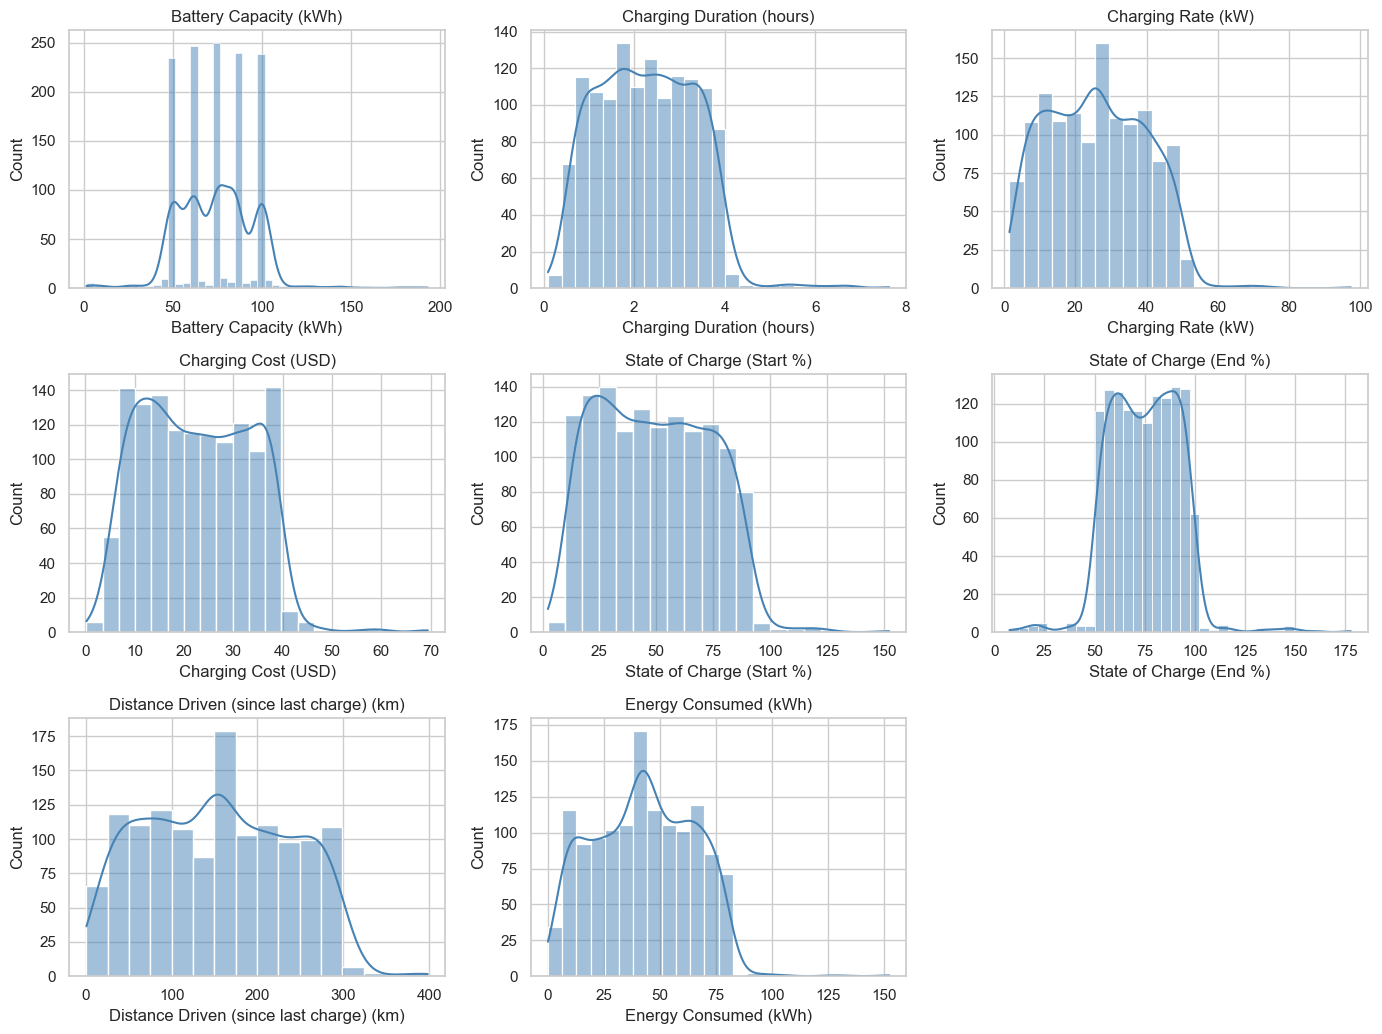

In [20]:
# Univariate: key numerics from raw-named columns (pre-dummy)
plot_cols = [
    c for c in [
        "Battery Capacity (kWh)",
        "Charging Duration (hours)",
        "Charging Rate (kW)",
        "Charging Cost (USD)",
        "State of Charge (Start %)",
        "State of Charge (End %)",
        "Distance Driven (since last charge) (km)",
        TARGET_COL,
    ]
    if c in data_clean.columns
]

n = len(plot_cols)
fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize=(14, 3.5 * int(np.ceil(n / 3))))
axes = np.array(axes).reshape(-1)
for i, col in enumerate(plot_cols):
    sns.histplot(data_clean[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


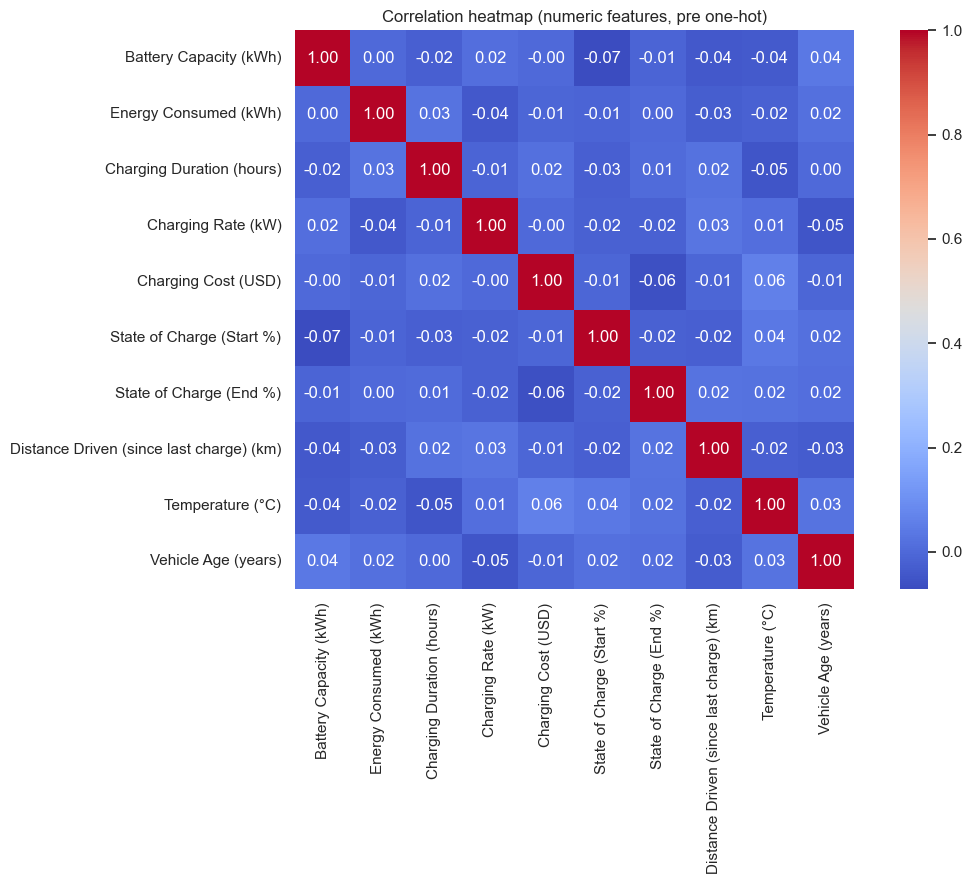

In [21]:
# Correlation among numeric columns in cleaned (pre-dummy) data
num_only = data_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 9))
sns.heatmap(num_only.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation heatmap (numeric features, pre one-hot)")
plt.tight_layout()
plt.show()


## Export: Processed Dataset + Splits

| Output | Description |
|--------|-------------|
| `4-ev_charging_patterns_processed.csv` | Full encoded + capped frame |
| `4-ev_charging_patterns_X_{train,val,test}.csv` | Standardized **X** |
| `4-ev_charging_patterns_y_{train,val,test}.csv` | Target **y** |

**Use case:** Compare driving / charging behaviors (session-level features vs energy delivered).


In [22]:
os.makedirs("data/processed", exist_ok=True)

full_processed = data_encoded.copy()
full_processed.to_csv("data/processed/4-ev_charging_processed.csv", index=False)
print("Saved:", full_processed.shape, "→ data/processed/4-ev_charging_processed.csv")

X_train_scaled.to_csv("data/processed/4-ev_charging_X_train.csv", index=False)
X_val_scaled.to_csv("data/processed/4-ev_charging_X_val.csv", index=False)
X_test_scaled.to_csv("data/processed/4-ev_charging_X_test.csv", index=False)
y_train.to_csv("data/processed/4-ev_charging_y_train.csv", index=False, header=True)
y_val.to_csv("data/processed/4-ev_charging_y_val.csv", index=False, header=True)
y_test.to_csv("data/processed/4-ev_charging_y_test.csv", index=False, header=True)

print("Saved train/val/test splits (StandardScaler on continuous columns).")
print("Target column:", TARGET_COL)


Saved: (1320, 37) → data/processed/4-ev_charging_patterns_processed.csv
Saved train/val/test splits (StandardScaler on continuous columns).
Target column: Energy Consumed (kWh)
